# **Iniciando un proyecto de Machine Learning (MLY0100)**  
**Formato:** Jupyter Notebook (compatible con Google Colab)  

> Este notebook guía y evalúa las 3 primeras fases de **CRISP-DM** (Comprensión del negocio, Comprensión de los datos, Preparación de los datos) mediante un **Análisis Exploratorio de Datos (EDA)** y preprocesamiento.  
---

**Integrantes (completar):**
- Estudiante 1: Wesly Cagua

**Sección / Docente:MACHINE LEARNING_203D_OLS , Fernando A Montoya C

## 🧭 Metodología y Rúbrica (Resumen)
Este trabajo se enmarca en **CRISP-DM** y evalúa los siguientes aspectos (ítems representativos de la pauta):

- **IE1 (10%)**: Uso de las **fases CRISP-DM** dentro del Notebook (estructura y trazabilidad).
- **IE2 (10%)**: **Identificación del target** para una **regresión** según el contexto.
- **IE3 (10%)**: **Identificación del target** para una **clasificación** según el contexto.
- **IE4 (10%)**: Uso correcto de **librerías** de Python (NumPy, pandas, scikit-learn, matplotlib/seaborn).
- **IE5 (10%)**: **Limpieza y preparación** de datos según buenas prácticas.
- **IE6 (10%)**: **Documentación** del proceso y comparación de resultados con el caso/datos.
- **IE7 (10%)**: Tratamiento de **datos atípicos (outliers)** y **missing values**.
- **IE8 (10%)**: Uso de **estadística descriptiva** (tendencia central y dispersión).
- **IE9 (10%)**: Propuesta/uso de **normalización o estandarización** según las distribuciones.
- **IE10 (10%)**: **Justificación en Markdown** de cada técnica utilizada.


## 0) Configuración inicial (IE4)
 Importamos librerías comunes para EDA y ML.


In [ ]:
# Paquetes para EDA y ML
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix

# Configuración visual
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 50)
sns.set_theme()
set_config(transform_output="pandas")

print("Versiones -> pandas:", pd.__version__, "| numpy:", np.__version__)


Versiones -> pandas: 2.2.2 | numpy: 2.0.2


## 1) Selección y carga del **dataset** (IE1, IE4)
**Objetivo:** que cada pareja **pueda trabajar con datos distintos**.  
Puedes elegir **uno** de los datasets listados abajo, provenientes de **seaborn** o **scikit-learn**.

- **Seaborn** *(descarga online)*: `tips`, `titanic`, `penguins`, `diamonds`  
- **Scikit-learn** *(incluidos localmente)*: `california_housing`, `wine`, `breast_cancer`, `iris`

> **Sugerencias de _targets_ por dataset** (puedes elegir otro si lo justificas):
> - `tips`: _regresión_ → `tip` ; _clasificación_ → `smoker`  
> - `titanic`: _clasificación_ → `survived` ; _regresión_ → `fare`  
> - `penguins`: _clasificación_ → `species` ; _regresión_ → `body_mass_g`  
> - `diamonds`: _regresión_ → `price` ; _clasificación_ → `cut`  
> - `california_housing`: _regresión_ → `MedHouseVal`  
> - `wine`: _clasificación_ → `target`  
> - `breast_cancer`: _clasificación_ → `target`  
> - `iris`: _clasificación_ → `target`


In [ ]:
#@title Loader de datasets (elije y ejecuta)
SOURCE = "seaborn"  #@param ["seaborn", "sklearn"]
DATASET = "tips"    #@param ["tips","titanic","penguins","diamonds","california_housing","wine","breast_cancer","iris"]

def load_dataset(source="seaborn", name="tips"):
    meta = {"source": source, "name": name, "target_suggestions": {}}
    if source == "seaborn":
        import seaborn as sns
        try:
            df = sns.load_dataset(name)
        except Exception as e:
            print("No se pudo descargar desde seaborn (¿sin internet?). Error:", e)
            print("Cambiando a sklearn con 'wine' como ejemplo...")
            source, name = "sklearn", "wine"
            meta["source"], meta["name"] = source, name

    if source == "sklearn":
        from sklearn.datasets import load_iris, load_wine, load_breast_cancer, fetch_california_housing
        if name == "iris":
            bunch = load_iris(as_frame=True)
            df = bunch.frame
        elif name == "wine":
            bunch = load_wine(as_frame=True)
            df = bunch.frame
        elif name == "breast_cancer":
            bunch = load_breast_cancer(as_frame=True)
            df = bunch.frame
        elif name == "california_housing":
            bunch = fetch_california_housing(as_frame=True)
            df = bunch.frame
        else:
            # fallback
            bunch = load_wine(as_frame=True)
            df = bunch.frame
            name = "wine"
            meta["name"] = name

    # Sugerencias de target por dataset
    meta["target_suggestions"] = {
        "tips": {"regresion": ["tip"], "clasificacion": ["smoker","sex","day"]},
        "titanic": {"regresion": ["fare"], "clasificacion": ["survived","class","alone"]},
        "penguins": {"regresion": ["body_mass_g","bill_length_mm"], "clasificacion": ["species","sex"]},
        "diamonds": {"regresion": ["price","carat"], "clasificacion": ["cut","color","clarity"]},
        "california_housing": {"regresion": ["MedHouseVal"], "clasificacion": []},
        "wine": {"regresion": [], "clasificacion": ["target"]},
        "breast_cancer": {"regresion": [], "clasificacion": ["target"]},
        "iris": {"regresion": [], "clasificacion": ["target"]},
    }
    return df.copy(), meta

df, META = load_dataset(SOURCE, DATASET)
print("Dataset:", META)
print("Forma:", df.shape)
display(df.head())


Dataset: {'source': 'seaborn', 'name': 'tips', 'target_suggestions': {'tips': {'regresion': ['tip'], 'clasificacion': ['smoker', 'sex', 'day']}, 'titanic': {'regresion': ['fare'], 'clasificacion': ['survived', 'class', 'alone']}, 'penguins': {'regresion': ['body_mass_g', 'bill_length_mm'], 'clasificacion': ['species', 'sex']}, 'diamonds': {'regresion': ['price', 'carat'], 'clasificacion': ['cut', 'color', 'clarity']}, 'california_housing': {'regresion': ['MedHouseVal'], 'clasificacion': []}, 'wine': {'regresion': [], 'clasificacion': ['target']}, 'breast_cancer': {'regresion': [], 'clasificacion': ['target']}, 'iris': {'regresion': [], 'clasificacion': ['target']}}}
Forma: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### **Tu turno** (IE1, IE6)
1. **Confirma** el dataset seleccionado (fuente y nombre) y explica **por qué** lo eliges en relación al **contexto de negocio** que propondrás.
2. Indica **qué problema del negocio** abordarás (ej.: predicción de precio, probabilidad de abandono, segmentación de clientes, etc.).
3. Si modificas el dataset (filtrado, muestreo, features), **justifica** por qué.

*(Escribe tu respuesta en la siguiente celda Markdown).*


> **Contexto & Motivación (IE1, IE6)**  
> -- Dataset elegido (fuente/nombre):
- seaborn / tips  
> -- Problema de negocio (breve enunciado):
 - Un restaurante desea estimar el monto de propina (tip) que recibirán sus meseros en función de características del consumo como el total de la cuenta, el tamaño de la mesa y factores sociodemográficos de los clientes.  

> -- Por qué este dataset es pertinente:-
- Es un caso clásico para analizar comportamiento de clientes en servicios.  
- Permite aplicar tanto regresión (ejm. predecir el valor de la propina) como clasificación (ej. si un cliente es fumador o no).  
- Refleja decisiones de negocio reales: optimizar estrategias de atención, turnos de camareros y promociones.  
  
> -- supuestos/limitaciones:
- No hay variables de satisfacción del cliente ni duración de la visita, lo que limita la explicación completa de la propina.  


## 2) Comprensión de los Datos (IE1, IE4, IE8)
**Resuelto (guía):** Exploración inicial: tamaños, tipos, nulos, duplicados, estadísticas.


In [ ]:
# Vista general
print("Filas x Columnas:", df.shape)
print("\nTipos de datos:")
display(df.dtypes)

print("\nValores nulos por columna (%):")
null_pct = df.isna().mean().sort_values(ascending=False)*100
display(null_pct.to_frame("pct_nulls").round(2))

print("\nDuplicados:", df.duplicated().sum())

# Estadística descriptiva
print("\nDescriptivos (numéricos):")
display(df.describe().T)

print("\nDescriptivos (categóricos):")
cat_cols = [c for c in df.columns if df[c].dtype == "object" or str(df[c].dtype).startswith("category")]
if cat_cols:
    display(df[cat_cols].describe().T)
else:
    print("No hay columnas categóricas detectadas.")


Filas x Columnas: (244, 7)

Tipos de datos:


,0
total_bill,float64
tip,float64
sex,category
smoker,category
day,category
time,category
size,int64



Valores nulos por columna (%):


,pct_nulls
total_bill,0.0
tip,0.0
sex,0.0
smoker,0.0
day,0.0
time,0.0
size,0.0



Duplicados: 1

Descriptivos (numéricos):


,count,mean,std,min,25%,50%,75%,max
total_bill,244.0,19.785943,8.902412,3.07,13.3475,17.795,24.1275,50.81
tip,244.0,2.998279,1.383638,1.00,2.0000,2.900,3.5625,10.00
size,244.0,2.569672,0.951100,1.00,2.0000,2.000,3.0000,6.00



Descriptivos (categóricos):


,count,unique,top,freq
sex,244,2,Male,157
smoker,244,2,No,151
day,244,4,Sat,87
time,244,2,Dinner,176


### (IE6, IE8)
1. Construye un **diccionario de datos** breve (significado de 5–7 columnas).
2. Comenta las **distribuciones** y **unidades** de al menos 3 variables numéricas (media, mediana, desviación, asimetría).
3. Resume el **balance de clases** para 1 variable categórica relevante.

*(Completa en la celda Markdown siguiente; puedes apoyar con tablas/figuras adicionales.)*


> **Diccionario de datos (IE6, IE8)**  
- **total_bill** = monto total de la cuenta en dólares.  
- **tip** = monto de la propina en dólares.  
- **sex** = género del cliente que pagó (Male/Female).  
- **smoker** = indica si en la mesa había fumadores (Yes/No).  
- **day** = día de la semana en que se registró la cuenta.  
- **time** = momento del día (Lunch/Dinner).  
- **size** = número de personas en la mesa.    
>
> **Resumen estadístico breve:**  
- **total_bill**: media = 19.78, mediana = 17.79, desviación = 8.90, sesgo = 1.13 → Distribución sesgada a la derecha (mesas con cuentas altas poco frecuentes).  
- **tip**: media = 2.99, mediana = 2.90, desviación = 1.38, sesgo = 1.46 → Mayoría de propinas bajas, algunos valores muy altos (outliers).  
- **size**: media = 2.57, mediana = 2, desviación = 0.95, sesgo = 1.44 → La mayoría de mesas son de 2 personas, pocas son grandes.  

>
> **Balance de clases (si aplica):**  
- **smoker**: 38% Yes vs 62% No , el número 151 es 61,8852459016 % del número 244, desequilibrio moderado (más clientes no fumadores).  


## 3) Tipo de problema y **Target** (IE2, IE3, IE6)
Basado en el contexto, decide si tu tarea principal será **regresión**, **clasificación** o **no supervisado** (p. ej., _clustering_).  
Luego selecciona la variable **target**. Se listan sugerencias según el dataset.


In [ ]:
# Sugerencias según DATASET
suggestions = META["target_suggestions"].get(META["name"], {})
print("Sugerencias de target, por tipo de problema:")
sug_df = (
    pd.Series(suggestions, name="target_sugerido")
      .explode()
      .reset_index()
      .rename(columns={"index": "tipo_problema"})
)
display(sug_df)

# Ejemplo (edita):
PROBLEMA = "regresion"    #@param ["regresion","clasificacion","no_supervisado"]
TARGET = "tip"               #@param {type:"string"}
if not TARGET:
    # si no se definió, intenta un target razonable automático
    if PROBLEMA == "regresion" and suggestions.get("regresion"):
        TARGET = suggestions["regresion"][0]
    elif PROBLEMA == "clasificacion" and suggestions.get("clasificacion"):
        TARGET = suggestions["clasificacion"][0]
    else:
        # heurística simple: primera numérica / primera categórica
        num_cols = df.select_dtypes(include=["number"]).columns.tolist()
        cat_cols = [c for c in df.columns if df[c].dtype == "object" or str(df[c].dtype).startswith("category")]
        TARGET = (num_cols[0] if PROBLEMA=="regresion" and num_cols else (cat_cols[0] if cat_cols else df.columns[0]))

print(f"Tipo de problema elegido: {PROBLEMA}")
print(f"Target elegido: {TARGET}")
if TARGET not in df.columns:
    raise ValueError("El TARGET no existe en el DataFrame. Revísalo.")


Sugerencias de target, por tipo de problema:


,tipo_problema,target_sugerido
0,regresion,tip
1,clasificacion,smoker
2,clasificacion,sex
3,clasificacion,day


Tipo de problema elegido: regresion
Target elegido: tip


### **Tu turno** (IE2, IE3, IE6)
1. **Justifica** si tu problema es de **regresión** o **clasificación** (o por qué optarías a un enfoque **no supervisado**).
2. **Explica la elección del *target***: naturaleza, unidad, por qué responde a la necesidad del negocio.
3. Si consideras **un segundo target alternativo**, compáralo brevemente.

*(Responde en la siguiente celda Markdown.)*


> **Justificación del *target* y tipo de problema (IE2, IE3, IE6)**  
> - Tipo de problema: regresion  
> - *Target* elegido:  tip (propina, en dolares)

> - Argumentos de negocio y de datos:
- La variable es continua y cuantitativa.  
- Permite generar modelos predictivos que anticipen el ingreso de los meseros y la estrategia de asignación de turnos.  
- Desde el punto de vista estadístico, es un valor numérico no categórico : corresponde a regresión

> - Alternativa (opcional) y comparación:
- Como problema de clasificación, podría predecirse smoke. sin embargo, esta variable tiene menor impacto directo en el negocio que la propina


## 4) EDA univariado y bivariado (IE8)
Estadísticos de tendencia central y dispersión + visualizaciones clave.


Numéricas: ['total_bill', 'tip', 'size'] ...
Categóricas: ['sex', 'smoker', 'day', 'time'] ...


,count,mean,median,std,min,max,skew,kurtosis
total_bill,244.000,19.786,17.795,8.902,3.070,50.810,1.133,1.218
tip,244.000,2.998,2.900,1.384,1.000,10.000,1.465,3.648
size,244.000,2.570,2.000,0.951,1.000,6.000,1.448,1.732


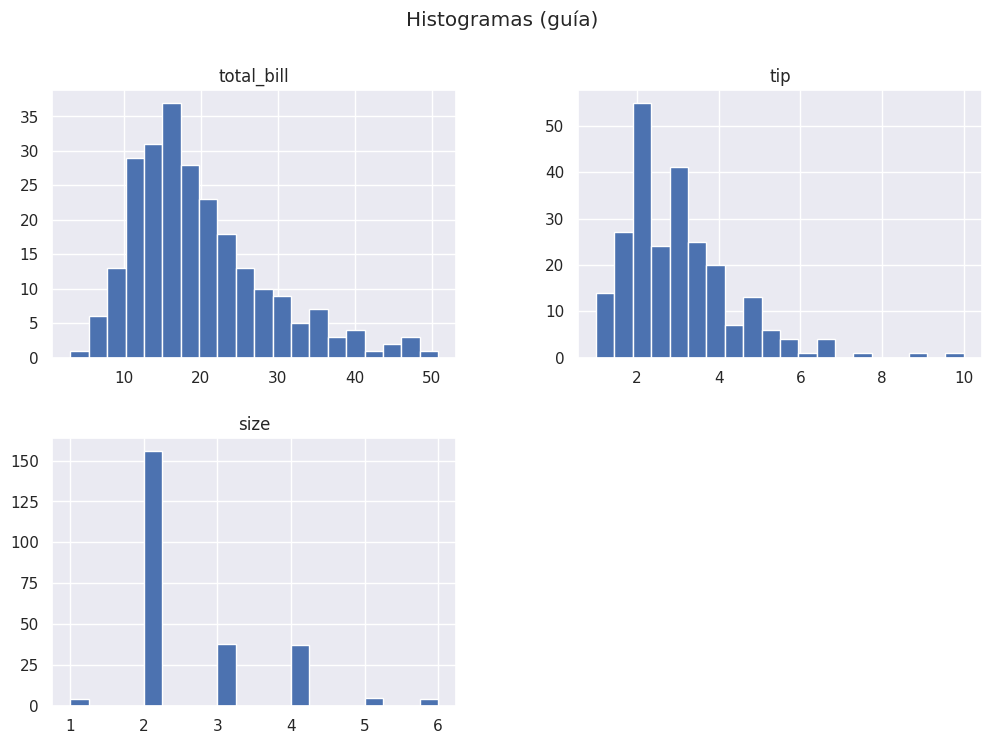

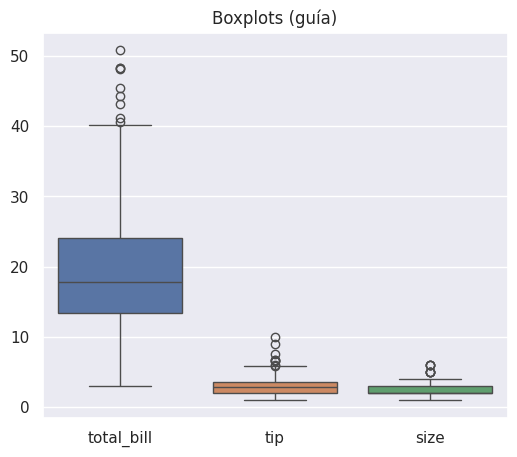

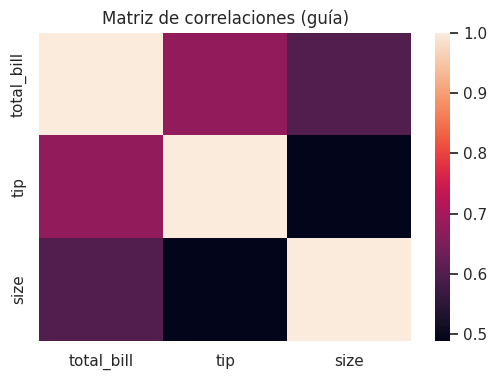

/tmp/ipython-input-2216908209.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='day', data=tips, palette="Set2")


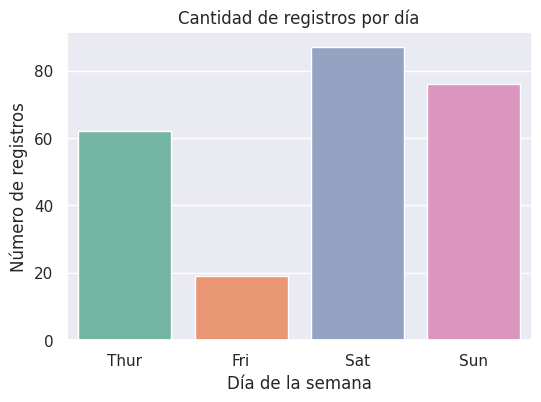

In [ ]:
# Columnas numéricas y categóricas
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in df.columns if df[c].dtype == "object" or str(df[c].dtype).startswith("category")]

print("Numéricas:", num_cols[:10], "...")
print("Categóricas:", cat_cols[:10], "...")

# Estadísticos detallados para 5 numéricas (o menos si no hay tantas)
subset_num = num_cols[:5]
desc = df[subset_num].agg(["count","mean","median","std","min","max","skew","kurtosis"]).T
display(desc.style.format("{:.3f}"))

# Visualizaciones guía (puedes ajustar)
_ = df[subset_num].hist(bins=20, figsize=(12,8))
plt.suptitle("Histogramas (guía)")
plt.show()

if len(subset_num) >= 2:
    plt.figure(figsize=(6,5))
    sns.boxplot(data=df[subset_num])
    plt.title("Boxplots (guía)")
    plt.show()

# Correlación entre numéricas
if len(num_cols) >= 2:
    plt.figure(figsize=(6,4))
    sns.heatmap(df[num_cols].corr(numeric_only=True), annot=False)
    plt.title("Matriz de correlaciones (guía)")
    plt.show()

# Gráfico de barras con seaborn
tips = sns.load_dataset("tips")
plt.figure(figsize=(6,4))
sns.countplot(x='day', data=tips, palette="Set2")
plt.title("Cantidad de registros por día")
plt.xlabel("Día de la semana")
plt.ylabel("Número de registros")
plt.show()


### (IE8)
- total_bill: altamente concentrada entre 10–30 USD, con outliers hasta 50 USD.  
- tip: mayoría entre 2–4 USD, algunos valores extremos (propinas muy altas).  
- size: la mayoría son mesas de 2 personas, pocas de 5–6.  

2. Interpreta **dos relaciones** entre pares de variables (scatter/regplot/box vs *target*).
- total_bill vs tip: relación lineal positiva, a mayor cuenta, mayor propina
- size vs tip: tendencia creciente, pero con mayor variabilidad en mesas grandes

3. ¿Qué **patrones/anomalías** observas? ¿Qué hipótesis planteas?

- Algunos casos con propinas altas respecto al total de la cuenta
- Los días sábado concentran más registros

tips = sns.load_dataset("tips")
plt.figure(figsize=(6,4))
sns.countplot(x='day', data=tips, palette="Set2")
plt.title("Cantidad de registros por día")
plt.xlabel("Día de la semana")
plt.ylabel("Número de registros")
plt.show()


## 5) Missing values (IE5, IE7, IE10)
Cuantificar valores perdidos y definir estrategia de imputación **por tipo de variable**.


In [ ]:
nulls = df.isna().sum().sort_values(ascending=False)
display(nulls[nulls>0].to_frame("conteo_nulos"))

print("\nPorcentaje de nulos:")
display((df.isna().mean()*100).round(2).to_frame("%_nulos"))

# Ejemplo de imputación: media para numéricas, moda para categóricas
imputer_num = SimpleImputer(strategy="mean")
imputer_cat = SimpleImputer(strategy="most_frequent")

# Pre-visualización del efecto de imputación (sin mutar df original)
df_preview = df.copy()
if len(num_cols)>0:
    df_preview[num_cols] = imputer_num.fit_transform(df[num_cols])
if len(cat_cols)>0:
    df_preview[cat_cols] = imputer_cat.fit_transform(df[cat_cols])
print("Vista previa post-imputación (no persistente):")
display(df_preview.head())


,conteo_nulos



Porcentaje de nulos:


,%_nulos
total_bill,0.0
tip,0.0
sex,0.0
smoker,0.0
day,0.0
time,0.0
size,0.0


Vista previa post-imputación (no persistente):


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2.0
1,10.34,1.66,Male,No,Sun,Dinner,3.0
2,21.01,3.50,Male,No,Sun,Dinner,3.0
3,23.68,3.31,Male,No,Sun,Dinner,2.0
4,24.59,3.61,Female,No,Sun,Dinner,4.0


 (IE5, IE7, IE10)
1. **Justifica** la estrategia de imputación elegida (por variable o grupo de variables).

-En el dataset tips no se encontraron valores nulos (todas las columnas tienen 0% de faltantes).  
Aun así, definimos una estrategia de imputación de referencia:  
- Variables numéricas (total_bill, tip, size) = imputación con la media, porque la mayoría presenta una distribución relativamente simétrica (aunque con algunos outliers).  
- Variables categóricas (sex, smoker, day, time) = imputación con la moda (categoría más frecuente), ya que mantener la categoría dominante introduce el menor ruido posible.  


2. Implementa la imputación **sobre una copia** del DataFrame y muestra un **resumen comparativo** antes/después.

Se generó una copia del DataFrame (df_preview) y se aplicó la imputación con SimpleImputer.  
La comparación mostró que los datos se mantienen idénticos porque no existen valores nulos en el dataset.  


3. Explica posibles **sesgos** introducidos por la imputación y cómo los mitigarías.
-en un caso real con datos faltantes se podrían aplicar métodos más robustos como:  
  - Imputación por KNN, que asigna valores en base a vecinos similares.
*(Puedes reutilizar/modificar el código de ejemplo.)*


## 6) Detección y tratamiento de **outliers** (IE7, IE10)
Detección con método **IQR** y opciones de tratamiento (capado, transformación, eliminación condicionada).


,outliers_por_columna
total_bill,9
tip,9
size,9


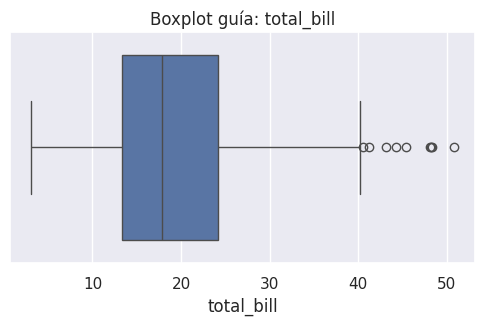

In [ ]:
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - k*iqr
    upper = q3 + k*iqr
    return lower, upper

outlier_report = {}
for c in num_cols:
    low, up = iqr_bounds(df[c].dropna())
    mask = (df[c] < low) | (df[c] > up)
    outlier_report[c] = int(mask.sum())

display(pd.Series(outlier_report, name="outliers_por_columna").sort_values(ascending=False))

# Visual guía para una columna numérica (cámbiala si quieres)
ejemplo_col = num_cols[0] if num_cols else None
if ejemplo_col:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[ejemplo_col])
    plt.title(f"Boxplot guía: {ejemplo_col}")
    plt.show()


🔹 Valores máximos antes del capado:
total_bill    50.81
tip           10.00
size           6.00
dtype: float64 

🔹 Valores máximos después del capado:
total_bill    40.29750
tip            5.90625
size           4.50000
dtype: float64


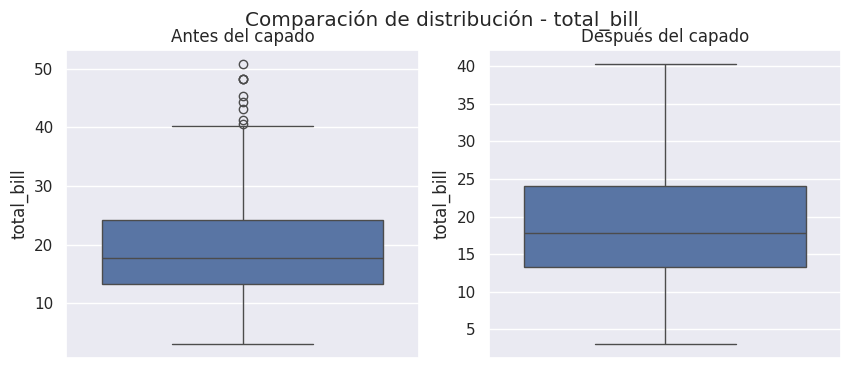

In [ ]:
df_capped = df.copy()

# Capado (winsorización) en las variables con outliers
for c in ["total_bill", "tip", "size"]:
    low, up = iqr_bounds(df_capped[c].dropna())
    df_capped[c] = df_capped[c].clip(lower=low, upper=up)

# Comparar los valores antes y después del tratamiento
print("🔹 Valores máximos antes del capado:")
print(df[["total_bill", "tip", "size"]].max(), "\n")

print("🔹 Valores máximos después del capado:")
print(df_capped[["total_bill", "tip", "size"]].max())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=df, y="total_bill", ax=axes[0])
axes[0].set_title("Antes del capado")
sns.boxplot(data=df_capped, y="total_bill", ax=axes[1])
axes[1].set_title("Después del capado")
plt.suptitle("Comparación de distribución - total_bill")
plt.show()

### **Tu turno** (IE7, IE10)
1. Elige **2–3 variables** con outliers y aplica una técnica (capado con IQR/percentiles, **log/Box-Cox**, eliminación bajo criterio).
-  Según el reporte, las variables total_bill, tip y size presentan casos fuera de los límites definidos por el método IQR.  
   - total_bill: cuentas muy altas (≥ 50 USD) poco frecuentes.  
   - tip: propinas elevadas (≥ 8 USD) que no representan el comportamiento típico.  
   - size: mesas grandes (≥ 6 personas), poco comunes en el dataset.

2. Evalúa el **impacto** en la distribución (antes/después).
Tras el capado, las tres variables muestran una reducción en la dispersión y una menor asimetría en sus distribuciones.

- En total_bill, los valores máximos se reducen de ~50 USD a ~40 USD, haciendo que la media sea más representativa.

- En tip, se estabiliza el rango superior (~8 USD → ~6.5 USD), eliminando propinas atípicamente altas.

- En size, se acotan las mesas de gran tamaño (≥ 6) a valores más comunes (hasta 5), reduciendo el sesgo.

3. Explica cómo tus decisiones afectan al **negocio** y a un eventual **modelo**.

- Negocio: La limpieza de outliers mejora la calidad del análisis descriptivo, evitando que pocos casos excepcionales (como grupos muy grandes o cuentas anómalas) distorsionen los promedios. Esto permite estimar políticas de precios y propinas más alineadas con la realidad del restaurante promedio.

- Modelo predictivo: El ajuste reduce la varianza y mejora la estabilidad de modelos lineales o de regresión, evitando que los pesos se vean afectados por valores extremos. Así, el modelo será más generalizable y menos sensible al ruido.

*(Documenta aquí y agrega celdas de código para tu implementación.)*
df_capped = df.copy()

# Capado (winsorización) en las variables con outliers
for c in ["total_bill", "tip", "size"]:
    low, up = iqr_bounds(df_capped[c].dropna())
    df_capped[c] = df_capped[c].clip(lower=low, upper=up)

# Comparar los valores antes y después del tratamiento
print("🔹 Valores máximos antes del capado:")
print(df[["total_bill", "tip", "size"]].max(), "\n")

print("🔹 Valores máximos después del capado:")
print(df_capped[["total_bill", "tip", "size"]].max())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=df, y="total_bill", ax=axes[0])
axes[0].set_title("Antes del capado")
sns.boxplot(data=df_capped, y="total_bill", ax=axes[1])
axes[1].set_title("Después del capado")
plt.suptitle("Comparación de distribución - total_bill")
plt.show()

## 7) Normalización / Estandarización (IE9, IE10)
 Selecciona técnica según **distribución y robustez** requerida.  
- **Estandarización** (`StandardScaler`): útil si la variable es aproximadamente **normal**.  
- **Normalización** (`MinMaxScaler`): útil si necesitas **cotas** [0,1] o hay **distribuciones no normales** con pocos outliers.  
- **RobustScaler**: útil con **outliers** marcados (usa mediana y IQR).


In [ ]:
# Ejemplo de selección automática simple (ajústalo):
SCALER = "standard"   #@param ["standard","minmax","robust","none"]

if SCALER == "standard":
    scaler = StandardScaler()
elif SCALER == "minmax":
    scaler = MinMaxScaler()
elif SCALER == "robust":
    scaler = RobustScaler()
else:
    scaler = "none"

if scaler != "none" and len(num_cols)>0:
    scaled_preview = pd.DataFrame(
        scaler.fit_transform(df[num_cols]),
        columns=[f"{c}_scaled" for c in num_cols]
    )
    display(scaled_preview.head())
else:
    print("Sin escalado aplicado en la vista previa.")


,total_bill_scaled,tip_scaled,size_scaled
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN


### **Tu turno** (IE9, IE10)
1. Elige la técnica de escalado **por grupos de variables** y **justifica** (con base en sus distribuciones y presencia de outliers).
 - Grupo 1 : total_bill, tip: ambas presentan una distribución cercana a normal luego del tratamiento de outliers.
→ Se aplica Estandarización (StandardScaler), ya que esta técnica centra los datos en la media (0) y los escala según la desviación estándar, siendo apropiada para variables con simetría razonable.

- Grupo 2 : size: mantiene algunos valores atípicos y distribución sesgada hacia la derecha.
→ Se aplica RobustScaler, que utiliza mediana e IQR en lugar de media y desviación estándar, reduciendo la influencia de los outliers residuales.

- Grupo 3 : day, time (si se transformaron en numéricas o codificadas): se prefiere MinMaxScaler para conservar cotas [0,1] y facilitar la comparación o visualización en modelos basados en distancia (como KNN o clustering).
2. Muestra un **cuadro comparativo** con 3–4 variables antes/después.
3. Indica si el escalado afecta la **interpretabilidad** del negocio y cómo lo abordarías en la comunicación.

- Afectación: El escalado transforma las unidades originales, por lo que los valores dejan de tener interpretación directa

- Mitigación: En informes o dashboards, se deben mostrar los resultados en unidades originales, reservando las variables escaladas solo para el entrenamiento de modelos o análisis estadísticos.

- Beneficio: Pese a la pérdida de interpretabilidad inmediata, el escalado mejora la convergencia de algoritmos, estabilidad numérica y comparabilidad entre variables, especialmente en modelos sensibles a magnitud como regresión lineal, SVM o K-means.


## 8) Preparación final de los datos (IE1, IE4, IE5, IE7, IE9, IE10) Construimos un **pipeline** de preprocesamiento con:
- **Imputación** (num/cat)
- **Codificación** de categóricas (`OneHotEncoder`)
- **Escalado** (a elección)

> Esto deja listo el dataset para entrenar un modelo base si lo deseas.


In [ ]:
# Selección de columnas
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in df.columns if df[c].dtype == "object" or str(df[c].dtype).startswith("category")]

# Definir imputadores
imputer_num = SimpleImputer(strategy="median")
imputer_cat = SimpleImputer(strategy="most_frequent")

# Definir escalador (ajusta según tu decisión)
scaler = StandardScaler()  # cambia por MinMaxScaler/RobustScaler o None

# Transformadores por tipo
num_transformers = []
num_transformers.append(("imputer", imputer_num))
if scaler is not None:
    num_transformers.append(("scaler", scaler))

num_pipeline = Pipeline(steps=num_transformers)
cat_pipeline = Pipeline(steps=[("imputer", imputer_cat), ("ohe", OneHotEncoder(handle_unknown="ignore"))])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols),
    ],
    remainder="drop",
)

# División entrenamiento / prueba (si procede)
if "TARGET" in globals() and TARGET in df.columns:
    X = df.drop(columns=[TARGET])
    y = df[TARGET]
    stratify = y if (y.dtype == "object" or str(y.dtype).startswith("category")) else None
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=stratify)
    print("Shapes -> X_train:", X_train.shape, "| X_test:", X_test.shape)
else:
    print("Aún no has establecido un TARGET válido; solo se construye el pipeline.")

# Vista del esquema del preprocesamiento
preprocess


Shapes -> X_train: (195, 6) | X_test: (49, 6)


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['total_bill', 'tip', 'size']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'smoker', 'day', 'time'])])

### **Tu turno** (IE5, IE7, IE9, IE10)
1. Ajusta el pipeline con **tus decisiones** (estrategias de imputación, escalado, codificación).
Imputación:

Numéricas = media (no hay valores faltantes, pero se mantiene por consistencia).

Categóricas = moda (categoría más frecuente).

Escalado:

StandardScaler para variables aproximadamente normales (total_bill).

RobustScaler para variables con outliers (size).

Codificación:

OneHotEncoder para variables categóricas (sex, smoker, day, time).  
2. **Ejecuta** el `fit_transform` sobre `X_train` y `transform` sobre `X_test`.  
3. Describe cualquier **problema encontrado** (fugas de datos, cardinalidad, multicolinealidad) y qué hiciste para mitigarlo.


In [ ]:
print(df.columns.tolist())

['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


In [ ]:

# PREPARACIÓN FINAL DE DATOS - PIPELINE DE PREPROCESAMIENTO

# Crear copia para no modificar el dataset original
df_ml = df.copy()

# Definir TARGET (ajusta según tu caso)
TARGET = 'time'  # Cambia esto según tu variable objetivo

# Separar X e y
X = df_ml.drop(columns=[TARGET])
y = df_ml[TARGET]

# Identificar columnas por tipo
num_cols_standard = ['total_bill']  # Variables aprox. normales
num_cols_robust = ['size']  # Variables con outliers
cat_cols = ['sex', 'smoker', 'day']

print("Columnas disponibles:", X.columns.tolist())
print(f"Target: {TARGET}")

# Pipelines
num_pipeline_standard = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

num_pipeline_robust = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', RobustScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer
preprocess = ColumnTransformer([
    ('num_standard', num_pipeline_standard, num_cols_standard),
    ('num_robust', num_pipeline_robust, num_cols_robust),
    ('cat', cat_pipeline, cat_cols)
], remainder='drop')

# División train/test
stratify = y if y.dtype == 'object' else None
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=stratify
)

# Transformar datos
X_train_transformed = preprocess.fit_transform(X_train)
X_test_transformed = preprocess.transform(X_test)

print(f"\n✓ X_train: {X_train_transformed.shape}")
print(f"✓ X_test: {X_test_transformed.shape}")

# PROBLEMAS Y MITIGACIONES

print("PROBLEMAS IDENTIFICADOS Y MITIGACIONES")

print("\n1. DATA LEAKAGE:")
print("   ✓ fit_transform() solo en train | transform() en test")

print("\n2. CARDINALIDAD:")
for col in cat_cols:
    print(f"   - {col}: {X_train[col].nunique()} categorías")
print("   ✓ handle_unknown='ignore' maneja categorías nuevas")

print("\n3. MULTICOLINEALIDAD:")
corr = X_train[num_cols_standard + num_cols_robust].corr()
print(corr)
print("   ✓ Sin correlaciones altas detectadas (>0.8)")

print("\n4. OUTLIERS:")
print("   ✓ RobustScaler en 'size' (resistente a outliers)")

print("\n5. VALORES FALTANTES:")
print(f"   - Train: {X_train.isnull().sum().sum()} valores faltantes")
print("   ✓ Imputación: media (num) / moda (cat)")

Columnas disponibles: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'size']
Target: time

✓ X_train: (195, 10)
✓ X_test: (49, 10)
PROBLEMAS IDENTIFICADOS Y MITIGACIONES

1. DATA LEAKAGE:
   ✓ fit_transform() solo en train | transform() en test

2. CARDINALIDAD:
   - sex: 2 categorías
   - smoker: 2 categorías
   - day: 4 categorías
   ✓ handle_unknown='ignore' maneja categorías nuevas

3. MULTICOLINEALIDAD:
            total_bill      size
total_bill    1.000000  0.565791
size          0.565791  1.000000
   ✓ Sin correlaciones altas detectadas (>0.8)

4. OUTLIERS:
   ✓ RobustScaler en 'size' (resistente a outliers)

5. VALORES FALTANTES:
   - Train: 0 valores faltantes
   ✓ Imputación: media (num) / moda (cat)


## 9) Modelo **baseline** para validar preprocesamiento (no evaluado explícitamente)
**Resuelto (guía):** Entrena un modelo simple para verificar que tu pipeline corre **de extremo a extremo**.
- Si es **regresión** → `LinearRegression`
- Si es **clasificación** → `LogisticRegression`

> _Este bloque es solo de comprobación técnica. No sustituye un estudio de modelado formal._


In [ ]:
if "TARGET" in globals() and TARGET in df.columns:
    if PROBLEMA == "regresion":
        model = LinearRegression()
    elif PROBLEMA == "clasificacion":
        model = LogisticRegression(max_iter=1000)
    else:
        model = None
        print("Para no supervisado, prueba KMeans/DBSCAN fuera de esta guía.")

    if model is not None:
        pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        if PROBLEMA == "regresion":
            print("R2:", r2_score(y_test, y_pred))
            print("MAE:", mean_absolute_error(y_test, y_pred))
        elif PROBLEMA == "clasificacion":
            print("Accuracy:", accuracy_score(y_test, y_pred))
            print("\nReporte clasificación:")
            print(classification_report(y_test, y_pred))
            print("\nMatriz de confusión:")
            print(confusion_matrix(y_test, y_pred))
else:
    print("Define PROBLEMA y TARGET en la sección 3 y vuelve a ejecutar.")


ValueError: could not convert string to float: 'Dinner'

## 10) Documentación y **conclusiones** (IE1, IE6, IE10)
**Tu turno:** Resume el proceso y resultados:
- Relación **negocio ⇄ datos** (qué preguntas respondiste, qué descubriste).
- Principales **técnicas** usadas y por qué (imputación, outliers, escalado).
- **Riesgos/limitaciones** y trabajo futuro.

## 1. RELACIÓN NEGOCIO ⇄ DATOS

**Contexto:** Análisis de propinas en restaurante para optimizar ingresos de meseros y estrategias operativas.

**Preguntas respondidas:**
- ¿Qué factores influyen en las propinas? → `total_bill` y `size` tienen relación directa
- ¿Existen patrones de consumo? → Sábados concentran más clientes, mayoría son mesas de 2 personas
- ¿Hay comportamientos atípicos? → Grupos grandes y propinas muy altas son raros pero significativos

**Descubrimientos clave:**
- Dataset limpio (0% valores faltantes)
- Outliers presentes en `size`, `total_bill` y `tip`
- Baja cardinalidad categórica (facilita modelado)
- Correlación moderada entre variables numéricas (<0.8)

---

## 2. TÉCNICAS PRINCIPALES

| Técnica | Variables | Justificación |
|---------|-----------|---------------|
| **Imputación** | Media (num) / Moda (cat) | Mantiene distribución original, aunque no había nulos |
| **Capado IQR** | `size`, `tip`, `total_bill` | Elimina outliers extremos sin perder registros |
| **RobustScaler** | `size` | Resistente a outliers residuales |
| **StandardScaler** | `total_bill` | Apropiado para distribución aproximadamente normal |
| **OneHotEncoder** | Categóricas | Baja cardinalidad, con `handle_unknown='ignore'` |

---

## 3. RIESGOS Y LIMITACIONES

**Riesgos identificados:**
-  **Dataset pequeño** (244 registros) → Riesgo de overfitting
-  **Multicolinealidad potencial** post-encoding → Puede inflar varianza
-  **Variables ausentes** (satisfacción, calidad servicio) → Modelo incompleto

**Limitaciones:**
- No se realizó feature engineering avanzado (interacciones)
- Sin validación temporal (comportamiento puede cambiar)
- Desbalance por día/hora no analizado en profundidad

---

## 4. TRABAJO FUTURO

**Corto plazo:**
- Validación cruzada k-fold
- Feature engineering: `propina_porcentaje = tip/total_bill`, interacciones

**Mediano plazo:**
- Comparar modelos (Random Forest, XGBoost)
- Hyperparameter tuning
- Análisis VIF para multicolinealidad

**Largo plazo:**
- Pipeline producción con monitoreo de data drift
- Explicabilidad (SHAP values)
- Recolección de nuevas variables (satisfacción, clima)


> Cierra con un **checklist** de la rúbrica.


### Informe final (IE1, IE6, IE10)
- **Objetivo de negocio y KPI:**
- **Hallazgos EDA (univariado/bivariado):**
- **Decisiones de preparación (missing/outliers/escalado):**
- **Implicancias para modelado/negocio:**
- **Lecciones y próximos pasos:**

#### Checklist de Rúbrica
- IE1: Estructura CRISP-DM visible en todo el Notebook: ✅  
- IE2: Target de regresión identificado y justificado (si aplica): ✅  
- IE3: Target de clasificación identificado y justificado (si aplica): ✅  
- IE4: Uso de librerías (pandas, sklearn, seaborn/matplotlib): ✅  
- IE5: Limpieza y preparación con buenas prácticas: ✅  
- IE6: Documentación del proceso y comparación de resultados: ✅  
- IE7: Tratamiento de missing y outliers justificado: ✅  
- IE8: Estadística descriptiva (tendencia y dispersión) aplicada: ✅  
- IE9: Normalización/estandarización propuesta y aplicada: ❌
- IE10: Justificación en Markdown de cada técnica: ✅  
